<a href="https://colab.research.google.com/github/MuhammadRhakan/forecasting-currency-volatility-with-basic-deep-learning/blob/main/foreign_exchange_rate_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time-Series Forecasting of GBP/IDR Exchange Rate

A review of fundamental deep learning approaches in time-series domain. This notebook implements and compares recurrent neural network architecture to understand the effectiveness in capturing temporal dependencies and financial patterns.

The primary objective is not to yield perfect model performance, but to understand its underlying architecture, also challenges in financial time-series data.

**Key Components (TL;DR)**
*   Implement basic deep learning model: `RNN`, `LSTM`, and `GRU`
*   Fetch exchange rate of GBR/IDR forex from Yahoo Finance
*   Examination of model suitability for financial forecasting

**Framework & Tools**
* Scikit-Learn  
* Tensorflow
* Keras



## Preliminary: Initial Data Exploration

This section emphasizes on analyzing behaviour of the dataset.

For simplicity, the analysis is limited to a univariate time series, where the *closing price* is used as the primary variable of interest.

In [1]:
# Import essential libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# Load dataset
# GBP/IDR exchange rate is fetched from Yahoo Finance site
# Available at: https://uk.finance.yahoo.com/quote/GBPIDR=X/

data = yf.download("GBPIDR=X", start="2015-01-01")
data.columns = data.columns.droplevel(1)
data.columns.name = None
data.index.name = None

data.tail()

/tmp/ipykernel_33868/2269168493.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("GBPIDR=X", start="2015-01-01")
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
2026-03-16,22436.634766,22586.074219,22463.562500,22475.589844,0
2026-03-17,22578.712891,22655.207031,22547.636719,22571.755859,0
2026-03-18,22664.119141,22657.015625,22514.511719,22655.169922,0
2026-03-19,22596.644531,22674.189453,22485.576172,22609.474609,0
2026-03-20,22634.570312,22793.839844,22530.050781,22771.130859,0


In [3]:
# Present visual exhange rate over time

def visualization(data: pd.Series):
    """
    Visualize the series using Plotly
    Due to GitHub limitation in presenting Plotly, an image is attached below
    """

    fig = px.line(data, title='Exchange Rate GBP/IDR 2015 to 2026')

    fig.update_layout(
        xaxis_title='Date',
        yaxis_title='Close Rate',
        template='plotly_dark',
        hovermode='x unified'
    )

    fig.show()


# Calling function
# visualization(data['Close'])

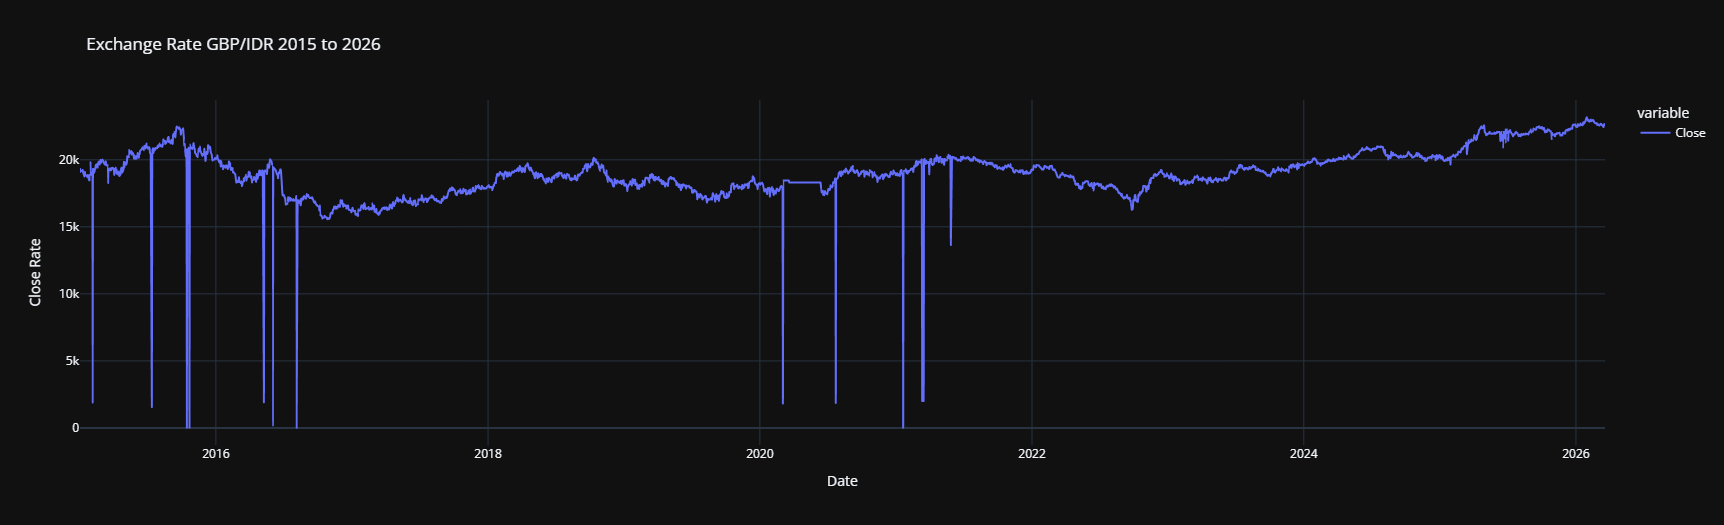

## Implementation: RNN vs LSTM vs GRU

This section implements and compares three fundamentals **recurrent neural network** architectures for time-series forecasting

In [4]:
# Import essentials packages

import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, GRU, Dense, BatchNormalization, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [8]:
def data_scaling(data: pd.Series):
    """
    Normalize series using MinMaxScaler into [0,1]

    Returns:
    scaler : MinMaxScaler object for later inverse transformation task.
    scaled_data : Normalized data.
    """

    reshaped_data = data.values.reshape(-1,1)
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(reshaped_data)

    return scaler, scaled_data

In [6]:
def create_dataset(data, time_step):
    """
    Transform a normalized time series into input-output sequences for model training.

    Time step : Number of previous time steps used as input features.
    """

    X, y = [], []

    # Mapping inputs and target
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

In [9]:
# Normalize the closing price series
scaler, scaled_data = data_scaling(data['Close'])

# Create sequences with a 30-day time step
X, y = create_dataset(scaled_data, time_step=30)

# Reshape input for RNN/LSTM/GRU: [samples, time_steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data to train, validate, and test
"""
Train: Main data used to fit the model
Val: Validation data to tune hyperparameters
Test: Unseen data to evalaute performance
"""
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

In [10]:
def evaluate_model(y_test, predictions):
    """
    Evaluate model predictions using regression metrics and plot results.
    The results are displayed in the same plot to compare actual vs predicted values
    """

    # Evaluation Metrics: MSE, RMSE, and MAE
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)

    # Print results
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

    # Visualize in lines
    plt.figure(figsize=(10,4))
    plt.plot(predictions, color='navy', alpha=0.3, label='Predicted')   # Predicted value
    plt.plot(y_test, color='purple', label='Actual')                    # Actual value

    plt.title('Prediction vs Actual Values')
    plt.grid(linestyle='--', alpha=0.3)
    plt.xlabel('Time Index')
    plt.ylabel('Forex Scaled')
    plt.legend()

    plt.tight_layout()
    plt.show()

### Vanilla Recurrent Neural Network

A basic RNN captures sequential dependencies by maintaining a hidden state across time steps. It is simple but may struggle with long-term dependencies due to vanishing gradients.

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1112
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0068
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0062
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0060
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0059
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0057
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0055
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0053
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0051
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0051
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0050
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0048
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0048
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052
E

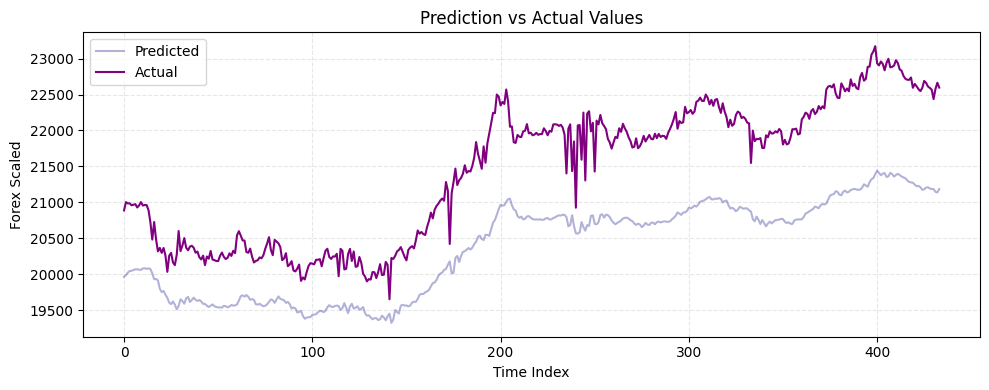

In [11]:
# Standard RNN pipeline
model = Sequential()
model.add(SimpleRNN(units=30, return_sequences=True, input_shape=(X_train.shape[1], 1)))    # First layer
model.add(SimpleRNN(units=30, return_sequences=False))  # Second layer
model.add(Dense(units=1))   # Output layer

# Compile the model and evaluate epoch using MSE
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=64)

# Generate prediction after training
predictions = model.predict(X_test)

# Inverse transform, evaluate performance, and show
predictions_actual = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
evaluate_model(y_test_actual, predictions_actual)

### Long-Short Term Memory

A developed version of RNNs that captures long-term dependencies in sequences. They use gates (input, forget, output) by preventing the vanishing gradient problem that standard RNNs struggle with.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Mean Squared Error (MSE): 1668575.98
Root Mean Squared Error (RMSE): 1291.73
Mean Absolute Error (MAE): 1177.99


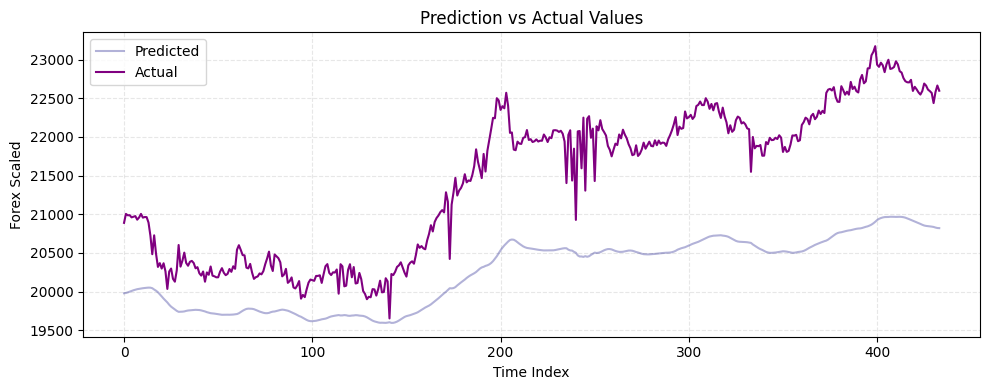

In [12]:
# LSTM pipeline
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),     # First layers
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32),   # Second layer
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='tanh'),   # Dense layer
    tf.keras.layers.Dense(1)    # Output
])

# Compile the model and evaluate epoch using MSE
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse')

# Callbacks for early stopping and learning rate adjustment
stoppage = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(patience=5)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0,
    callbacks=[stoppage, lr_scheduler],
    shuffle=False
)

# Generate prediction after training
predictions = model.predict(X_test)

# Inverse transform, evaluate performance, and show
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

evaluate_model(y_test_actual, predictions)

### Gated Recurrent Units

A simplified alternative to LSTMs, using fewer gates while still effectively capturing long-term dependencies. This pipeline uses bidirectional GRUs, batch normalization, and dropout for more robust modeling.

Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 0.7960 - val_loss: 0.5613 - learning_rate: 5.0000e-04
Epoch 2/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.4249 - val_loss: 0.6164 - learning_rate: 5.0000e-04
Epoch 3/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.2762 - val_loss: 0.8456 - learning_rate: 5.0000e-04
Epoch 4/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.1674 - val_loss: 1.0364 - learning_rate: 5.0000e-04
Epoch 5/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.1253 - val_loss: 1.0864 - learning_rate: 5.0000e-04
Epoch 6/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0952 - val_loss: 1.5208 - learning_rate: 5.0000e-04
Epoch 7/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0822 - val_loss: 1.7137 - learning_rate: 2.5000e-04
Epoch 8/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0702 - val_loss: 1.5996 - learning_rate: 2.5000e-04
Epoch 9/250
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0688 - val_loss: 1.0238 - learning_ra

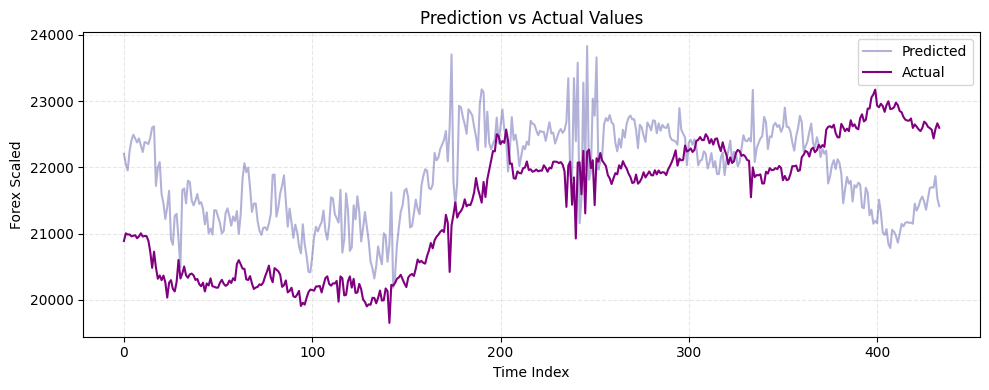

In [13]:
# Build GRU pipeline
model = Sequential([
    Bidirectional(GRU(64, return_sequences=True, input_shape=(X_train.shape[1], 1))),   # First layer
    BatchNormalization(),
    Dropout(0.2),
    GRU(32),    # Second layer
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='tanh'),   # Dense layer
    Dense(1)    # Output
])

# Compile the model and evaluate epochs using MSE
model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

# Early stoppage and learning rate adjustment
stoppage = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model
model.fit(
    X_train, y_train,
    epochs=250,
    batch_size=32,
    validation_split=0.1,
    callbacks=[stoppage, lr_scheduler],
    shuffle=False,
    verbose=1
)

# Generate predictions
predictions = model.predict(X_test)

# Inverse transform, evaluate performance, and show
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

evaluate_model(y_test_actual, predictions)